<p align="center"><img src="https://github.com/uchiharon/ANN-Overfitting-Lab/blob/main/Images/University_of_Texas_at_Austin_seal.svg.png?raw=true" width="200" height="200" /></p>

# Forward Modeling -- Wave propagation

### **Emmanuel Ikpesu**
### **ei3294**
#### **Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering**

# Q2.1 Inverse with AD

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

Using device: cuda


In [3]:
# Define parameters and initial conditions
dx = 0.001
dt = 0.0005
x = torch.arange(0, 1 + dx, dx).to(device)
t = torch.arange(0, 2.0 + dt, dt).to(device)
c = 1.0
u_x0 = torch.sin(np.pi * x) + 0.5 * torch.sin(3 * np.pi * x)
du_dtx0 = torch.zeros(len(x)).to(device)
u_0t = torch.zeros(len(t)).to(device)
u_Lt = torch.zeros(len(t)).to(device)

In [4]:
# Test CFL condition
CFL = c * dt / dx

print(f"CFL number: {CFL}")
if CFL > 1:
    raise ValueError("CFL condition not met! Reduce dt or increase dx.")

CFL number: 0.5


In [5]:
# True wave speed
c_true = 0.9 + 0.1 * x  # linear from 0.9 to 1.0

# Sensor locations
sensor_idx = torch.round(torch.tensor([0.15, 0.35, 0.5, 0.7, 0.85]) / dx).long()

In [6]:
sensor_idx

tensor([150, 350, 500, 700, 850])

In [7]:
# Finite Difference Solver for 1D Wave Equation
def fd_solver(u_x0, du_dtx0, u_0t, u_Lt, c, dx, dt):
    """Finite Difference Solver for 1D Wave Equation.
    Args:
        u_x0 (torch.ndarray): Initial displacement at t=0.
        du_dtx0 (torch.ndarray): Initial velocity at t=0.
        u_0t (torch.ndarray): Boundary condition at x=0 for all t.
        u_Lt (torch.ndarray): Boundary condition at x=L for all t.
        c (float): Wave speed.
        dx (float): Spatial step size.
        dt (float): Time step size.
    Returns:
        torch.ndarray: Displacement u(x,t) over space and time.
    """
    n = len(u_x0) - 1
    m = len(u_0t) - 1
    u = torch.zeros((m + 1, n + 1)).to(device)
    u[0, :] = u_x0
    u[:, 0] = u_0t
    u[:, -1] = u_Lt


    # First time step
    u[1, 1:-1] = (u[0, 1:-1] + du_dtx0[1:-1] * dt 
                               + 0.5 * c[1:-1]**2 * (u[0, 2:] - 2 * u[0, 1:-1] + u[0, 0:-2]) * (dt**2) / (dx**2))
    # Time-stepping loop
    for j in range(1, m):
                u[j + 1, 1:-1] = (2 * u[j, 1:-1] - u[j - 1, 1:-1] 
                               + c[1:-1]**2 * (u[j, 2:] - 2 * u[j, 1:-1] + u[j, 0:-2]) * (dt**2) / (dx**2))
    return u

In [8]:
# Generate synthetic observations
with torch.no_grad():
    u_true = fd_solver(u_x0, du_dtx0, u_0t, u_Lt, c_true, dx, dt)


u_obs = u_true[:, sensor_idx] + torch.randn_like(u_true[:, sensor_idx]) * 1e-4

In [9]:
len(x), dx

(1001, 0.001)

In [10]:
# # 1. Fine grid for c(x) → exactly 10,000 points (as requested)
# Nx_c = 101
# x_fine = torch.linspace(0.0, 1.0, Nx_c, device=device, dtype=torch.float64)
# c_true_fine = 0.9 + 0.1 * x_fine                   # true c(x)
# c_est      = (0.85 + 0.15 * x_fine).clone().requires_grad_(True)   # initial guess


# # 3. Interpolate c_est from 10,000 points → 401 points every time the solver is called
# def get_c_on_coarse_grid():
#     # Linear interpolation (very cheap and fully differentiable!)
#     return torch.nn.functional.interpolate(
#         c_est.reshape(1, 1, Nx_c),               # (1,1,10000)
#         size=len(x),                                  # target size
#         mode='linear',
#         align_corners=False
#     ).squeeze()                                   # → shape (Nx,)


# optimizer = torch.optim.LBFGS([c_est], lr=1, max_iter=50, tolerance_grad=1e-20)

# losses = []

# def closure():
#     optimizer.zero_grad()
#     c_coarse = get_c_on_coarse_grid()
#     u_pred = fd_solver(u_x0, du_dtx0, u_0t, u_Lt, c_coarse, dx, dt)
#     loss = torch.mean((u_pred[:, sensor_idx] - u_obs)**2)
#     loss.backward()
#     losses.append(loss.item())
#     print(f"Iter {len(losses):2d} → Loss = {loss.item():.3e}")
#     return loss

# print("Starting inversion...")
# optimizer.step(closure)
# print("Done!")

In [11]:
# 1. Fine grid for c(x) → exactly 10,000 points (as requested)
c_est = (0.85 + 0.15 * x).clone().requires_grad_(True)   # initial guess

optimizer = torch.optim.LBFGS([c_est], lr=1, max_iter=50, tolerance_grad=1e-9, tolerance_change=1e-9)

losses = []

def closure():
    optimizer.zero_grad()
    u_pred = fd_solver(u_x0, du_dtx0, u_0t, u_Lt, c_est, dx, dt)
    loss = torch.mean((u_pred[:, sensor_idx] - u_obs)**2)
    loss.backward()
    losses.append(loss.item())
    print(f"Iter {len(losses):2d} → Loss = {loss.item():.3e}")
    return loss

print("Starting inversion...")
optimizer.step(closure)
print("Done!")

Starting inversion...
Iter  1 → Loss = 1.001e-02
Iter  2 → Loss = 9.310e-03
Iter  3 → Loss = 1.753e-04
Iter  4 → Loss = 1.253e-04
Iter  5 → Loss = 8.280e-05
Iter  6 → Loss = 2.956e-05
Iter  7 → Loss = 1.027e-05
Iter  8 → Loss = 7.342e-06
Iter  9 → Loss = 5.391e-06
Iter 10 → Loss = 2.785e-06
Iter 11 → Loss = 1.458e-06
Iter 12 → Loss = 9.441e-07
Iter 13 → Loss = 8.587e-07
Iter 14 → Loss = 7.560e-07
Iter 15 → Loss = 6.413e-07
Iter 16 → Loss = 5.284e-07
Iter 17 → Loss = 4.598e-07
Iter 18 → Loss = 4.288e-07
Iter 19 → Loss = 4.164e-07
Iter 20 → Loss = 3.810e-07
Iter 21 → Loss = 3.587e-07
Iter 22 → Loss = 1.778e-07
Iter 23 → Loss = 1.007e-07
Iter 24 → Loss = 4.399e-08
Iter 25 → Loss = 3.939e-08
Iter 26 → Loss = 3.824e-08
Done!


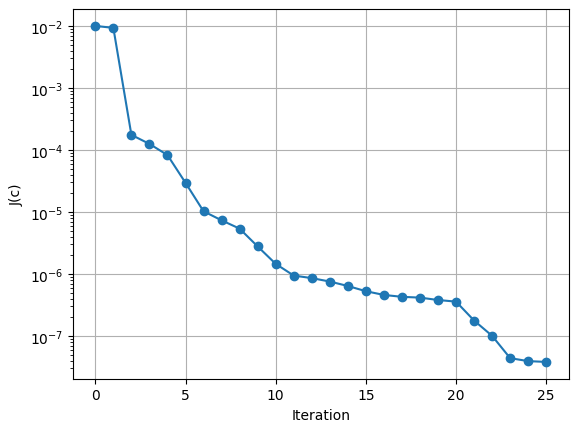

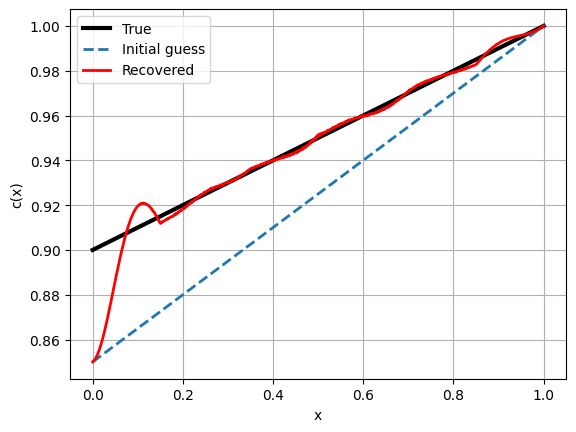

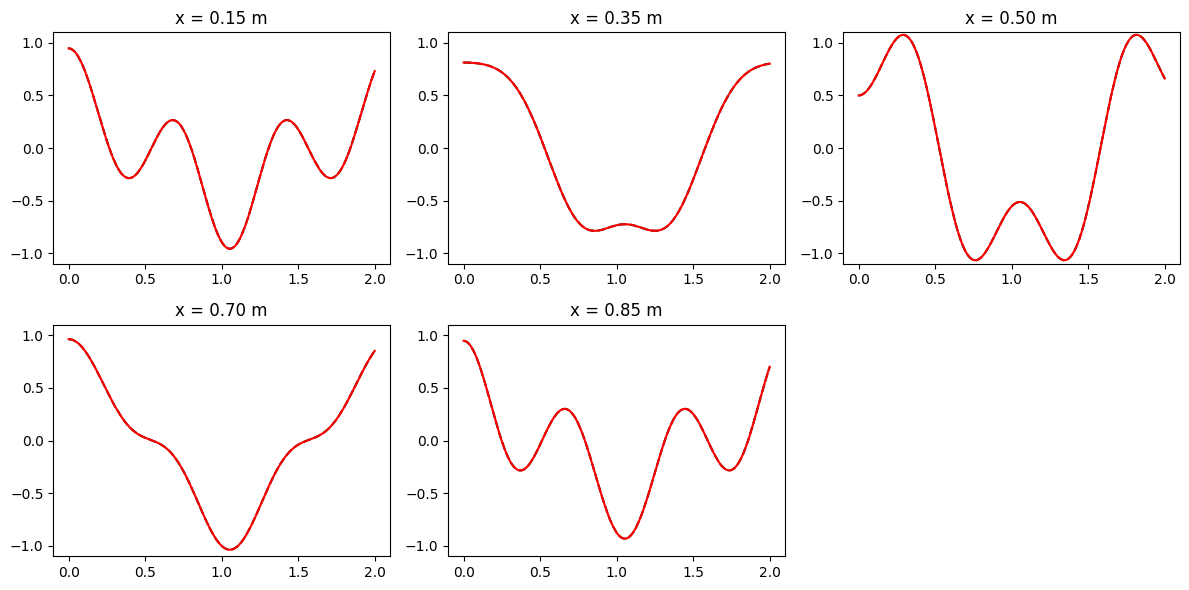

In [12]:
# Convergence
plt.figure(); plt.semilogy(losses, 'o-'); plt.xlabel('Iteration'); plt.ylabel('J(c)'); plt.grid()

# Recovered c(x)
plt.figure()
plt.plot(x.cpu(), c_true.cpu(), 'k', lw=3, label='True')
plt.plot(x.cpu(), (0.85 + 0.15*x).cpu(), '--', lw=2, label='Initial guess')
plt.plot(x.cpu(), c_est.detach().cpu(), 'r-', lw=2, label='Recovered')
plt.legend(); plt.xlabel('x'); plt.ylabel('c(x)'); plt.grid()

# Time series at sensors
u_final = fd_solver(u_x0, du_dtx0, u_0t, u_Lt, c_est.detach(), dx, dt)
t_vec = torch.linspace(0.0, 2.0, len(t))
plt.figure(figsize=(12,6))
for i, idx in enumerate(sensor_idx):
    plt.subplot(2,3,i+1)
    plt.plot(t_vec, u_obs[:,i].cpu(), 'k--', label='Obs (noisy)')
    plt.plot(t_vec, u_final[:,idx].cpu(), 'r-', label='Predicted')
    plt.title(f'x = {sensor_idx[i] * dx:.2f} m')
    plt.ylim(-1.1,1.1)
plt.tight_layout()

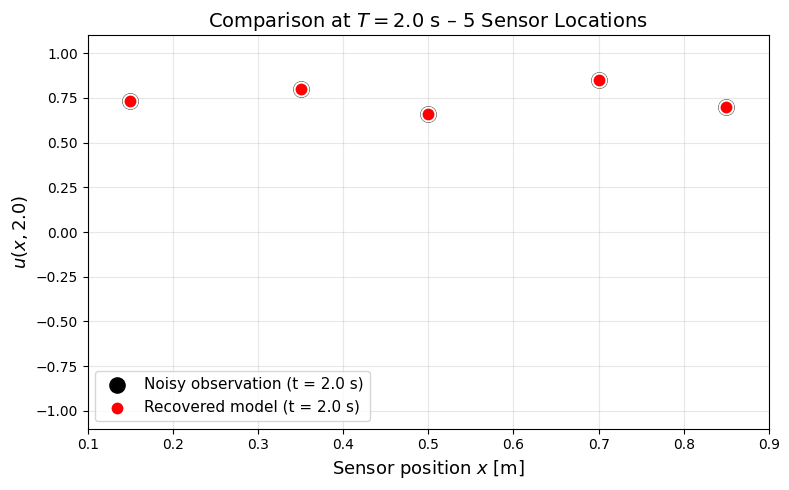

In [13]:
# Extract only the very last time step (t = 2.0 s)
u_obs_at_T2   = u_obs[-1, :].cpu().numpy()      # noisy observations at 5 sensors
u_final_at_T2 = u_final[-1, sensor_idx].cpu().numpy()  # predicted with recovered c

sensor_positions = [0.15, 0.35, 0.50, 0.70, 0.85]

# PLOT – exactly what you need for deliverable iii (strict reading)
plt.figure(figsize=(8, 5))

# Noisy observations
plt.scatter(sensor_positions, u_obs_at_T2, 
            c='black', s=120, label='Noisy observation (t = 2.0 s)', zorder=5)

# Final recovered model
plt.scatter(sensor_positions, u_final_at_T2, 
            c='red', s=100, marker='o', edgecolors='white', linewidth=1.5,
            label='Recovered model (t = 2.0 s)', zorder=6)

# Connect with lines for clarity (optional but looks nice)
for i in range(5):
    plt.plot([sensor_positions[i], sensor_positions[i]], 
             [u_obs_at_T2[i], u_final_at_T2[i]], 
             color='gray', alpha=0.6, linewidth=1.2)

plt.xlabel('Sensor position $x$ [m]', fontsize=13)
plt.ylabel('$u(x, 2.0)$', fontsize=13)
plt.title('Comparison at $T = 2.0$ s – 5 Sensor Locations', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0.1, 0.9)
plt.ylim(-1.1, 1.1)
plt.tight_layout()
plt.show()

## Executive Summary

##### **iv) Explain the difference between forward and reverse mode AD and explain when will you use which approach?**

|Feature|Forward-Mode AD|Reverse-Mode AD (Backpropagation)|
|-------|---------------|---------------------------------|
|Direction|Same as function evaluation (forward)|Opposite to function evaluation (backward)|
|What it computes|Derivative of all outputs w.r.t. one input|Derivative of one output w.r.t. all inputs|
|Cost per gradient|Proportional to # inputs|Proportional to # outputs|
|Memory usage|Low (no graph storage)|Higher (stores computation graph)|
|Best when| Few inputs, many outputs|Many inputs, one (or few) outputs|
|Typical use case|Sensitivity analysis, physics sims|Training neural networks|